In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Lab 9 - Multi-layer Perceptron Forward Pass & Backpropagation

## Part I
For this exercise you will implement a simple 2-layer perceptron with the forward pass and the backpropagation to learn the weights

For the first part you'll build and train a 2-layer neural network that predicts the prices of houses, using the usual Boston housing dataset.

In [2]:
housing_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
boston = pd.read_table("housing.txt", names=housing_names, sep="\s+")

As usual, consider the MEDV as your target variable. 
* Split the data into training, validation and testing (70,15,15)%
* Experiment with different number of neurons per layer for your network, using the validation set

In [3]:
X = boston.values[:,:-1]
y = boston.values[:,-1]

In [4]:
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size= 0.7)
X_test, X_val, y_test, y_val = train_test_split(X_aux, y_aux, train_size= 0.5)


In [5]:
class ActivationFunction:
    
    def __init__(self, function, derivative = None):
        self.function = function
        self.derivative = derivative
        
def sigmoid(a): return 1/(1 + np.exp(-a))
def sigmoid_prime(a): return sigmoid(a) * (1 - sigmoid(a))

sigmoid_activation = ActivationFunction(sigmoid, sigmoid_prime)

def softmax(a):
    exp_a = np.exp(a)
    return exp_a / exp_a.sum(axis=1, keepdims=True)

def identity(a): return a

In [6]:
def sse(target, y_prev): return np.sum((target - y_prev)**2) * 0.5

def cross_entropy_multiclass(target, y_prev): 
    n = len(target)
    return - np.sum(np.multiply(target, np.log(y_prev))) / n

In [7]:
class MultilayerPerceptron:

    def __init__(self, hidden_activation: ActivationFunction, output_activation, sizes: list):
        """A lista "sizes" deve conter todos as dimensões das camadas da nossa rede, desde a dimensão de entrada
        até a de saída. Tanto os pesos, quanto os biases estarão na matriz de parâmetros."""

        self.num_layers = len(sizes) - 1
        self.num_hidden_layers = len(sizes) - 2
        self.sizes = sizes
        self.hidden_activation = hidden_activation.function
        self.hidden_activation_prime = hidden_activation.derivative
        self.output_activation = output_activation
        self.parameters = [np.random.randn(y, x + 1) for x,y in zip(sizes[:-1], sizes[1:])]
    

    def _initialize_parameters(self):
        self.parameters = [np.random.randn(y, x + 1) for x,y in zip(self.sizes[:-1], self.sizes[1:])]
    

    @staticmethod
    def _add_ones(X):
        """Essa função vai nos permitir adicionar uma coluna de 1s aos nossos dados, para conseguirmos 
        multiplicar pelos biases."""
        return np.column_stack((np.ones(X.shape[0]), X))
    

    def _forward_pass(self, X):
        z = self._add_ones(X)
        Zs = [z]
        As = []
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            As.append(a)
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)
            Zs.append(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y, Zs, As
    

    def _fast_forward_pass(self, X):
        """Realiza o forward_pass sem ficar armazendo os valores necessários para o backpropagation."""
        z = self._add_ones(X)
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y
        

    @staticmethod
    def _output_derivative(y_prev, target):
        """Calcula o delta de saída."""
        return y_prev - target
    
    

In [8]:
class MultilayerPerceptronRegression(MultilayerPerceptron):
    
    def __init__(self, hidden_activation, output_activation, sizes):
        super().__init__(hidden_activation, output_activation, sizes)
    
    def backpropagation(self, X, y):
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)

        n_out = y_pred.shape[1]
        if n_out == 1:
            y_enc = y.reshape(-1, 1)          

        delta = self._output_derivative(y_pred, y_enc)  
        delta_w[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w
    
    def predict(self, X):
        y_pred = self._fast_forward_pass(X)
        
        if y_pred.shape[1] == 1:
            y_pred = y_pred.flatten()
            
        return y_pred
    def fit(self, 
            X_train, 
            y_train, 
            X_val,
            y_val,
            update_method = "mini_batch",
            batch_size = 32, 
            lr = 0.01, 
            epochs=1, 
            weight_decay = 0.0):
        
        """Treina os parâmetros da nossa rede utilizando o método de mini-batch. Os casos do Stochastic Gradient Descent (SGD)
        e do método batch, são os casos especiais em que batch_size = 1 e batch_size = X.shape[0] (número de data points), respectivamente."""

        if update_method == "sgd": batch_size = 1
        if update_method == "batch": batch_size = X_train.shape[0]
            
        n_samples = X_train.shape[0]
        loss_history_train, loss_history_val = [], [] 

        for epoch in range(epochs):

            for start in range(0, n_samples, batch_size):
                X_batch = X_train[start : start + batch_size]
                y_batch = y_train[start : start + batch_size]

                delta_w = self.backpropagation(X_batch, y_batch)

                for i, dw in enumerate(delta_w):
                    
                    if weight_decay > 0:
                        regularization = np.zeros_like(self.parameters[i])
                        regularization[:, 1:] = weight_decay * self.parameters[i][:, 1:] 
                        dw = dw + regularization
                    
                    self.parameters[i] -= lr * dw

            y_pred_train = self._fast_forward_pass(X_train)
            y_pred_val = self._fast_forward_pass(X_val)
            loss_history_train.append(self.compute_loss(y_train, y_pred_train))
            loss_history_val.append(self.compute_loss(y_val, y_pred_val))

        return loss_history_train, loss_history_val
    
    @staticmethod
    def sse(target, y_prev): return np.sum((target - y_prev)**2) * 0.5

    @staticmethod
    def rmse(target, y_prev): return np.sqrt(np.mean((target - y_prev)**2))

    def compute_loss(self, target, y_pred):
        if target.ndim != y_pred.ndim: y_pred = y_pred.flatten()
        return self.rmse(target, y_pred)
    
    

In [9]:
class MultilayerPerceptronClassification(MultilayerPerceptron):

    def __init__(self, hidden_activation, output_activation, sizes):
        super().__init__(hidden_activation, output_activation, sizes)
        self.num_classes = sizes[-1]
    
    @staticmethod
    def _one_hot(y, num_classes):
        """Converte labels inteiros em matriz com uns nas classes correspondentes"""
        Y = np.zeros((len(y), num_classes))
        Y[np.arange(len(y)), y] = 1
        return Y
        
    def backpropagation(self, X, y):
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)

        if y.ndim == 1:
            y_target  = self._one_hot(y, self.num_classes)         

        delta = self._output_derivative(y_pred, y_target)  
        delta_w[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:]) 
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w
    
    def predict(self, X):
        return self._fast_forward_pass(X)
    
    def predict_classes(self, X):
        """Retorna o índice da classe com maior probabilidade."""
        y_pred = self._fast_forward_pass(X)
        return np.argmax(y_pred, axis=1)
    
    def fit(self, 
            X_train, 
            y_train, 
            X_val,
            y_val,
            update_method = "mini_batch",
            batch_size = 32, 
            lr = 0.01, 
            epochs=1, 
            weight_decay = 0.0):
        
        """Treina os parâmetros da nossa rede utilizando o método de mini-batch. Os casos do Stochastic Gradient Descent (SGD)
        e do método batch, são os casos especiais em que batch_size = 1 e batch_size = X.shape[0] (número de data points), respectivamente."""

        if update_method == "sgd": batch_size = 1
        if update_method == "batch": batch_size = X_train.shape[0]
            
        n_samples = X_train.shape[0]
        loss_history_train, loss_history_val = [], [] 

        for epoch in range(epochs):

            for start in range(0, n_samples, batch_size):
                X_batch = X_train[start : start + batch_size]
                y_batch = y_train[start : start + batch_size]

                delta_w = self.backpropagation(X_batch, y_batch)

                for i, dw in enumerate(delta_w):
                    
                    if weight_decay > 0:
                        regularization = np.zeros_like(self.parameters[i])
                        regularization[:, 1:] = weight_decay * self.parameters[i][:, 1:] 
                        dw = dw + regularization
                    
                    self.parameters[i] -= lr * dw

            y_pred_train = self._fast_forward_pass(X_train)
            y_pred_val = self._fast_forward_pass(X_val)
            loss_history_train.append(self.compute_loss(y_train, y_pred_train))
            loss_history_val.append(self.compute_loss(y_val, y_pred_val))

        return loss_history_train, loss_history_val
    
    def cross_entropy_multiclass(self, target, y_pred):
        t = self._one_hot(target, self.num_classes)
        n = len(target)
        return - np.sum(t * np.log(y_pred)) / n 
    
    def compute_loss(self, target, y_pred):
        return self.cross_entropy_multiclass(target, y_pred)

In [10]:
MLP = MultilayerPerceptronRegression(sigmoid_activation, identity, [13, 6, 1])
lht, lhv = MLP.fit(X_train, y_train, X_val, y_val, "mini_batch", 1, 0.001, 70, 0.001)
y_prev = MLP.predict(X_train)

C:\Users\sodre\AppData\Local\Temp\ipykernel_11564\1096152351.py:7: RuntimeWarning: overflow encountered in exp
  def sigmoid(a): return 1/(1 + np.exp(-a))


In [11]:
MLP.sse(y_train, y_prev)


13724.848646317101

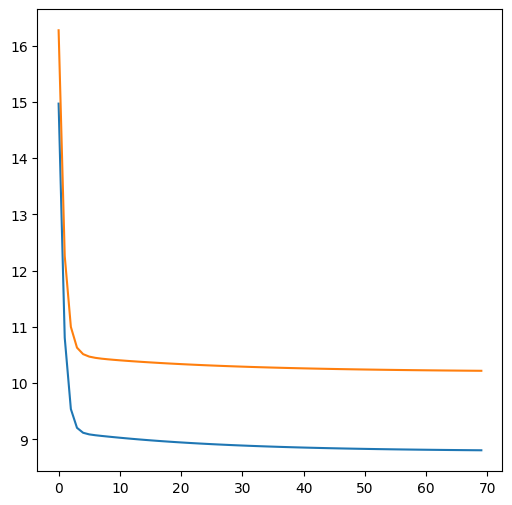

In [12]:
fig = plt.figure(figsize = (6,6))
plt.plot(lht)
plt.plot(lhv)

## Part II 

For this exercise you will build and train a 2-layer neural network that predicts the exact digit from a hand-written image, using the MNIST dataset. 
For this exercise, add weight decay to your network.

In [13]:
from sklearn.datasets import load_digits

In [14]:
digits = load_digits()

In [15]:
X = digits.data
y = digits.target

In [16]:
X.shape

(1797, 64)

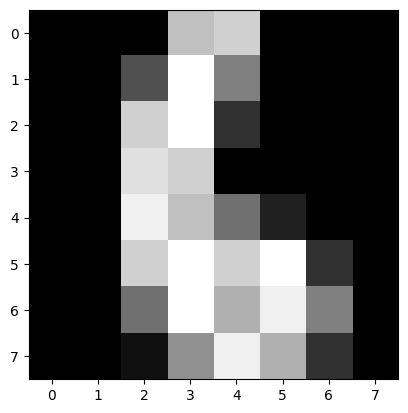

In [29]:
plt.imshow(X[6].reshape(8,8), cmap= "gray")

Again, you will split the data into training, validation and testing.

In [17]:
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size= 0.7)
X_test, X_val, y_test, y_val = train_test_split(X_aux, y_aux, train_size= 0.5)

In [18]:
y_train

array([7, 6, 7, ..., 3, 3, 6])

In [19]:
MLP = MultilayerPerceptronClassification(sigmoid_activation, softmax, [64, 14, 10])
lht, lhv = MLP.fit(X_train, y_train, X_val, y_val, "mini_batch", 2, 0.01, 50, 1e-2)
y_pred = MLP.predict(X_val)

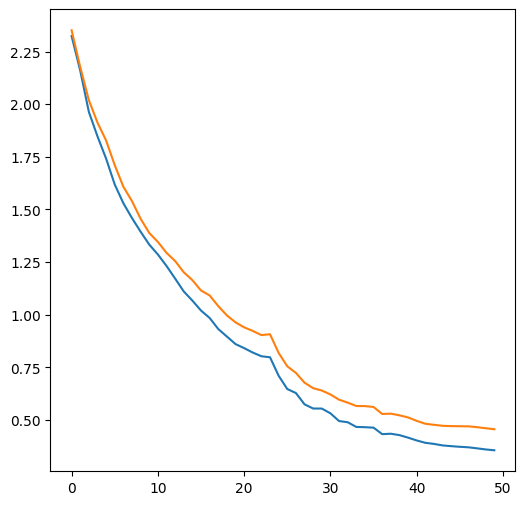

In [20]:
fig = plt.figure(figsize = (6,6))
plt.plot(lht)
plt.plot(lhv)

In [21]:
MLP.cross_entropy_multiclass(y_val, y_pred)

0.45615978388878087

In [22]:
MLP.predict_classes(X_val)

array([1, 3, 9, 4, 9, 5, 2, 7, 0, 7, 0, 4, 5, 6, 3, 2, 7, 8, 2, 6, 6, 0,
       1, 6, 0, 3, 4, 4, 1, 5, 8, 1, 1, 4, 5, 9, 8, 4, 3, 6, 2, 0, 8, 1,
       9, 9, 7, 7, 9, 4, 1, 2, 3, 1, 5, 7, 8, 6, 6, 9, 7, 8, 9, 5, 9, 2,
       1, 2, 1, 5, 9, 4, 4, 8, 4, 2, 6, 5, 7, 5, 9, 3, 2, 6, 9, 4, 6, 1,
       9, 5, 3, 0, 6, 1, 9, 7, 1, 3, 7, 5, 9, 7, 9, 1, 0, 5, 1, 2, 6, 1,
       7, 5, 0, 1, 3, 4, 8, 1, 1, 4, 5, 2, 7, 9, 5, 6, 9, 6, 5, 7, 9, 9,
       7, 2, 2, 4, 4, 6, 1, 2, 5, 2, 0, 5, 6, 6, 9, 3, 5, 4, 5, 6, 5, 3,
       3, 1, 0, 3, 7, 6, 3, 0, 7, 8, 7, 2, 9, 9, 1, 6, 9, 7, 6, 9, 8, 5,
       4, 7, 5, 5, 0, 7, 7, 9, 7, 7, 7, 1, 6, 4, 3, 5, 8, 0, 6, 5, 2, 2,
       0, 1, 8, 8, 6, 5, 6, 5, 3, 6, 3, 6, 4, 7, 1, 7, 7, 2, 8, 4, 8, 6,
       2, 3, 7, 9, 0, 3, 8, 3, 1, 5, 4, 6, 4, 2, 1, 9, 1, 4, 5, 0, 1, 5,
       7, 7, 7, 8, 6, 0, 4, 4, 7, 4, 1, 6, 5, 8, 2, 1, 2, 7, 9, 9, 8, 6,
       4, 8, 9, 9, 4, 4], dtype=int64)

In [30]:
y_val

array([1, 3, 9, 4, 9, 5, 2, 7, 0, 7, 0, 4, 5, 5, 3, 2, 7, 8, 2, 6, 6, 0,
       1, 6, 0, 3, 4, 4, 1, 5, 8, 1, 9, 4, 5, 9, 4, 4, 3, 6, 2, 0, 8, 1,
       9, 9, 7, 7, 9, 4, 1, 2, 3, 1, 3, 7, 8, 6, 6, 9, 7, 8, 1, 5, 9, 2,
       1, 2, 1, 8, 9, 4, 4, 8, 4, 2, 6, 5, 7, 5, 9, 3, 2, 6, 9, 4, 6, 1,
       9, 5, 3, 0, 6, 8, 9, 7, 1, 3, 7, 5, 9, 7, 9, 1, 0, 5, 6, 2, 8, 1,
       7, 5, 0, 8, 3, 4, 8, 1, 1, 4, 5, 2, 7, 9, 5, 6, 1, 6, 3, 7, 9, 9,
       8, 2, 2, 4, 4, 6, 1, 2, 5, 2, 0, 8, 6, 6, 9, 3, 5, 4, 5, 6, 5, 3,
       3, 1, 0, 3, 7, 6, 3, 0, 7, 8, 7, 2, 9, 9, 1, 0, 9, 7, 6, 9, 8, 5,
       4, 7, 5, 5, 0, 7, 8, 9, 7, 7, 7, 1, 6, 4, 3, 5, 8, 0, 6, 5, 2, 2,
       0, 1, 8, 8, 6, 5, 6, 5, 3, 6, 3, 6, 4, 7, 4, 7, 7, 8, 8, 4, 8, 6,
       2, 3, 7, 5, 0, 3, 8, 3, 1, 5, 4, 6, 4, 9, 1, 9, 1, 4, 5, 0, 2, 5,
       7, 7, 7, 8, 6, 0, 4, 4, 7, 4, 1, 6, 5, 8, 3, 7, 2, 7, 9, 9, 8, 6,
       4, 8, 9, 9, 4, 4])